Exercises

E01: I did not get around to seeing what happens when you initialize all weights and biases to zero. Try this and train the neural net. You might think either that 1) the network trains just fine or 2) the network doesn't train at all, but actually it is 3) the network trains but only partially, and achieves a pretty bad final performance. Inspect the gradients and activations to figure out what is happening and why the network is only partially training, and what part is being trained exactly.

E02: BatchNorm, unlike other normalization layers like LayerNorm/GroupNorm etc. has the big advantage that after training, the batchnorm gamma/beta can be "folded into" the weights of the preceeding Linear layers, effectively erasing the need to forward it at test time. Set up a small 3-layer MLP with batchnorms, train the network, then "fold" the batchnorm gamma/beta into the preceeding Linear layer's W,b by creating a new W2, b2 and erasing the batch norm. Verify that this gives the same forward pass during inference. i.e. we see that the batchnorm is there just for stabilizing the training, and can be thrown out after training is done! pretty cool.italicized text

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
words = open('names.txt','r').read().splitlines()

In [3]:
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [4]:
len(words)

32033

In [9]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)
len(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


27

In [10]:
block_size = 3
def build_dataset(words):
  X,Y =[],[]
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape,Y.shape)
  return X,Y

In [11]:
import random
random.seed(42)
random.shuffle(words)

In [12]:
n1 = int(len(words)*0.8)
n2 = int(len(words)*0.9)


In [13]:
Xtr,Ytr= build_dataset(words[:n1])
Xdev,Ydev= build_dataset(words[n1:n2])
Xte,Yte= build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [14]:
n_emdb =100
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,n_emdb),generator=g)
W1 = torch.randn((n_emdb*block_size,n_hidden),generator=g) * (5/3) / ((n_emdb*block_size)**0.5)
b1 = torch.randn(n_hidden,generator=g) * 0.01
W2 = torch.randn((n_hidden,27),generator=g) / ((n_hidden)**0.5)
b2 = torch.randn(27,generator=g) * 0.01

bngain = torch.ones(1,n_hidden)
bnbias = torch.zeros(1,n_hidden)
bnmean_running = torch.zeros(1,n_hidden)
bnstd_running = torch.ones(1,n_hidden)

parameters = [C,W1,b1,W2,b2,bngain,bnbias]
print(f"Total parameters :{sum(p.nelement() for p in parameters)}")
for p in parameters:
  p.requires_grad = True


Total parameters :35727


In [16]:
max_steps = 200000
lossi = []
for i in range(max_steps):
  ix = torch.randint(0,Xtr.shape[0],(32,),generator=g)
  Xb,Yb = Xtr[ix],Ytr[ix]
  emb = C[Xb]
  embcat = emb.view(emb.shape[0],-1)
  hpreact = embcat @ W1 + b1
  bnmeani = hpreact.mean(0,keepdim=True)
  bnstdi = hpreact.std(0,keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.99 * bnmean_running + 0.01 * bnmeani
    bnstd_running = 0.99 * bnstd_running + 0.01 * bnstdi
  h = torch.tanh(hpreact)
  logits = h @ W2 +b2
  loss = F.cross_entropy(logits,Yb)

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10000 == 0:
     print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 2.4513
  10000/ 200000: 1.9517
  20000/ 200000: 2.1118
  30000/ 200000: 2.5337
  40000/ 200000: 1.7503
  50000/ 200000: 2.2928
  60000/ 200000: 1.8034
  70000/ 200000: 2.2321
  80000/ 200000: 1.7586
  90000/ 200000: 1.7192
 100000/ 200000: 2.2246
 110000/ 200000: 2.0157
 120000/ 200000: 2.2090
 130000/ 200000: 2.1653
 140000/ 200000: 1.7848
 150000/ 200000: 2.1659
 160000/ 200000: 2.1917
 170000/ 200000: 2.2178
 180000/ 200000: 2.1793
 190000/ 200000: 2.1751


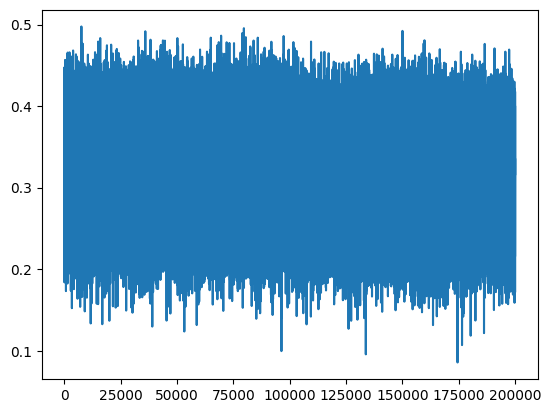

In [17]:
plt.plot(lossi)

In [22]:
def split_loss(split):
  X = {'train' : Xtr,'val':Xdev,'test':Xte}
  Y = {'train' : Ytr,'val':Ydev,'test':Yte}
  with torch.no_grad():
    emb = C[X[split]].view(-1,n_emdb*3)
    hpreact = emb @ W1 + b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Y[split])
    print(split,loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 2.0473358631134033
val 2.0998005867004395
test 2.1007702350616455


In [31]:
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

In [32]:
n_emdb=10
n_hidden=100
vocab_size =27
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_emdb),generator=g)

In [35]:
block_size =3
layers = [
    Linear(n_emdb*block_size,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size,bias=False),BatchNorm1d(vocab_size)

]

In [36]:
with torch.no_grad():
  layers[-1].gamma *= 0.1

In [37]:
for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


In [38]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
     ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])



      0/ 200000: 3.3081
  10000/ 200000: 2.2145
  20000/ 200000: 2.2798
  30000/ 200000: 2.0592
  40000/ 200000: 2.1182
  50000/ 200000: 2.1501
  60000/ 200000: 2.3169
  70000/ 200000: 2.4828
  80000/ 200000: 1.9583
  90000/ 200000: 2.2437
 100000/ 200000: 2.1840
 110000/ 200000: 1.8210
 120000/ 200000: 1.8391
 130000/ 200000: 1.9713
 140000/ 200000: 1.7368
 150000/ 200000: 2.4379
 160000/ 200000: 2.2882
 170000/ 200000: 2.0436
 180000/ 200000: 2.4503
 190000/ 200000: 2.0464


layer 2 --> mean : -0.007 std : 0.722 saturation : 22.9%
layer 5 --> mean : -0.010 std : 0.758 saturation : 25.9%
layer 8 --> mean : 0.018 std : 0.779 saturation : 27.8%
layer 11 --> mean : 0.012 std : 0.784 saturation : 29.7%
layer 14 --> mean : -0.002 std : 0.798 saturation : 31.9%


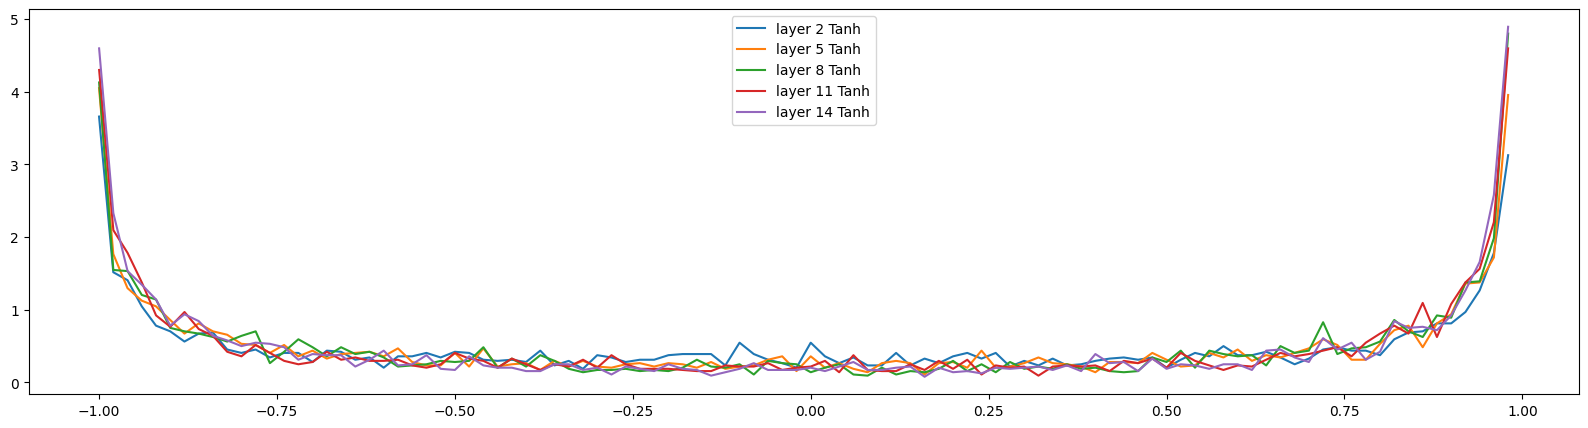

In [45]:
plt.figure(figsize=(20,5))
for i,layer in enumerate(layers):
    if isinstance(layer, Tanh):
        t = layer.out
        print(f"layer {i} --> mean : {t.mean():.3f} std : {t.std():.3f} saturation : {(t.abs() > 0.95).float().mean()*100:.1f}%")
        hy, hx = torch.histogram(t, density=True)
        hx2 = hx[:-1].to(torch.device('cpu')).detach().numpy()
        hy2 = hy.to(torch.device('cpu')).detach().numpy()
        plt.plot(hx2 , hy2, label=f'layer {i} {layer.__class__.__name__}')
plt.legend();

layer 2 (      Tanh): mean +0.000000, std 2.938513e-03
layer 5 (      Tanh): mean +0.000000, std 3.096498e-03
layer 8 (      Tanh): mean +0.000000, std 3.119567e-03
layer 11 (      Tanh): mean -0.000000, std 3.047722e-03
layer 14 (      Tanh): mean +0.000000, std 3.150705e-03


Text(0.5, 1.0, 'gradient distribution')

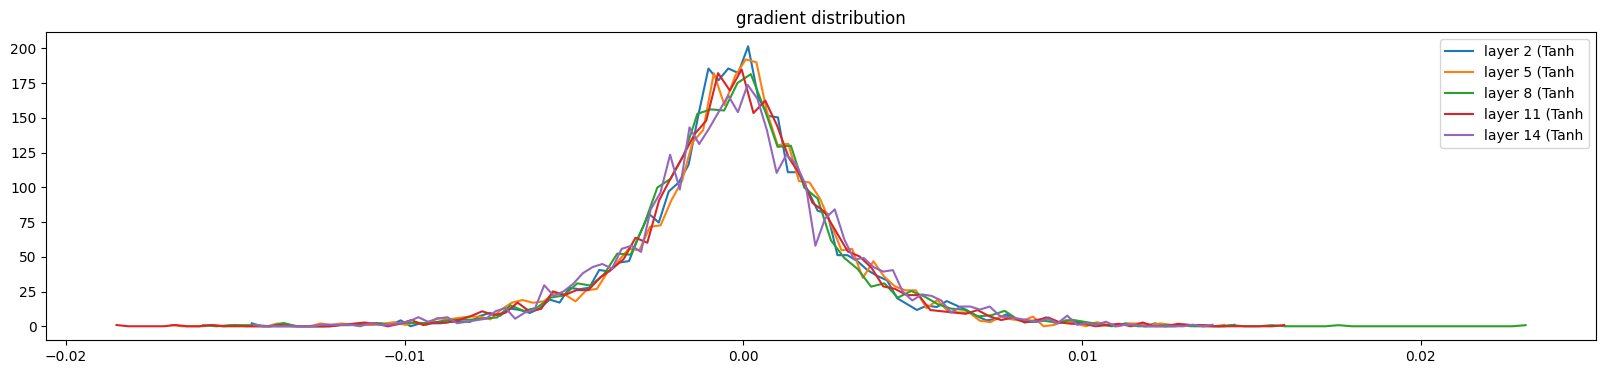

In [46]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 1.223389e-02 | grad:data ratio 1.072997e-02
weight  (30, 100) | mean -0.000157 | std 6.826213e-03 | grad:data ratio 1.706260e-02
weight (100, 100) | mean +0.000008 | std 4.669329e-03 | grad:data ratio 1.936837e-02
weight (100, 100) | mean -0.000013 | std 4.851758e-03 | grad:data ratio 2.025764e-02
weight (100, 100) | mean -0.000016 | std 4.578042e-03 | grad:data ratio 1.992070e-02
weight (100, 100) | mean -0.000007 | std 4.481666e-03 | grad:data ratio 2.062352e-02
weight  (100, 27) | mean -0.000045 | std 6.239725e-03 | grad:data ratio 1.771583e-02


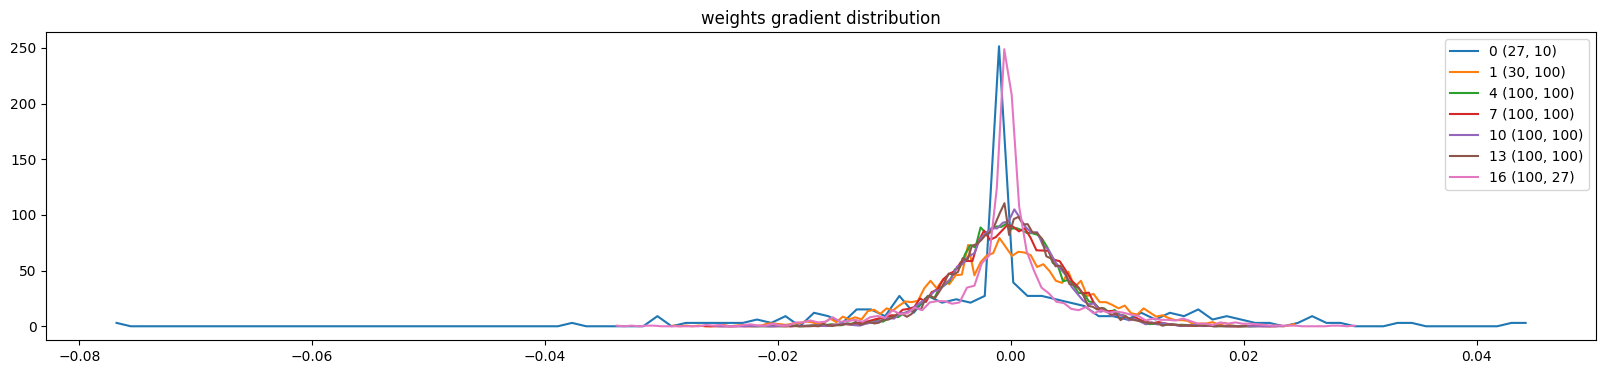

In [47]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

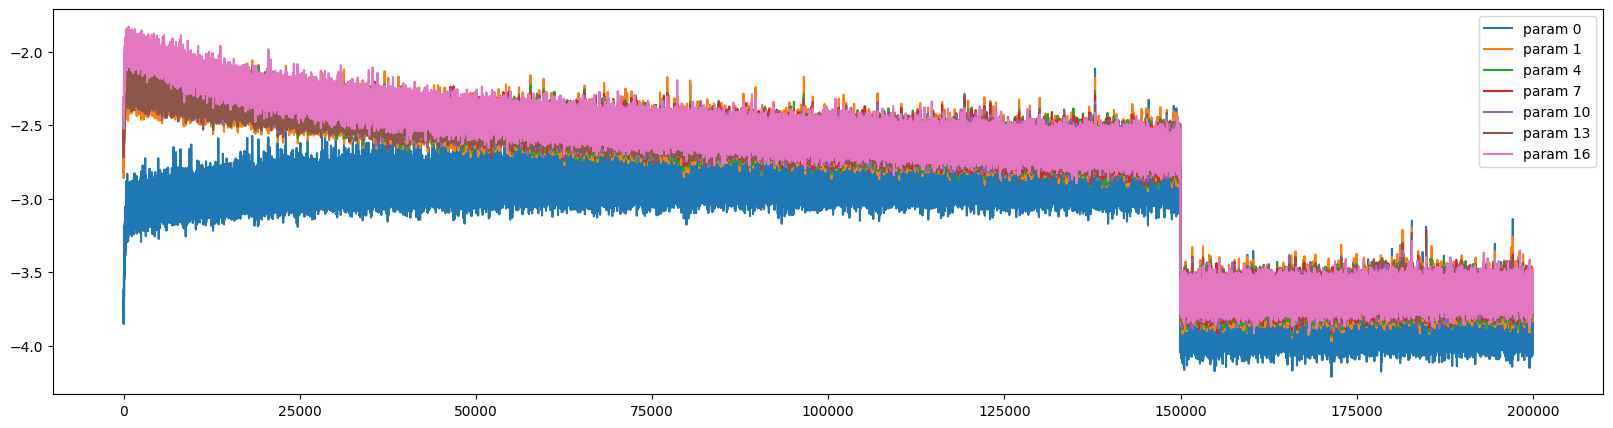

In [49]:
plt.figure(figsize=(20,5))
for i,p in enumerate(parameters):
    if p.ndim==2:
        plt.plot([ud[j][i] for j in range(len(ud))], label=f'param {i}')
plt.legend();

In [51]:
@torch.no_grad()
def split_loss(split):
  X,Y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[X]
  x = emb.view(-1,n_emdb * block_size)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x,Y)
  print(split,loss.item())


for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')
split_loss('test')



train 1.9997104406356812
val 2.081305742263794
test 2.0819530487060547


In [56]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        x = emb.view(-1, n_emdb*block_size)
        for layer in layers:
            x = layer(x)
        probs = torch.softmax(x, dim=1)
        next = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [next]
        out.append(next)
        if next==0:
            break
    print(''.join([itos[i] for i in out]))

carmah.
ambrilli.
kimri.
reigh.
skanden.
jazhuba.
deliah.
jareei.
nellara.
chaiiv.
kaleigh.
ham.
joce.
quinton.
lilea.
jadiquinte.
madiarynn.
jace.
pius.
brex.
